# Carga de datos

In [31]:
import pyreadr
import pandas as pd


resultados = pyreadr.read_r('nacXanioMes.RData')
df_nac = resultados['nacXanioMes']


Vamos a convertir el df de nacimiento

In [32]:
df_nac['fecha'] = pd.to_datetime(df_nac['Anio'].astype(str) + '-' + df_nac['Mes'].astype(str).str.zfill(2))
df_nac.set_index('fecha', inplace=True)


In [33]:
df_nac = df_nac.drop(df_nac.columns[:2], axis=1)

In [34]:
df_nac = df_nac.sort_index(ascending=True)

In [35]:
df_nac

,Cantidad
fecha,
2009-01-01,30715
2009-02-01,26078
2009-03-01,29319
2009-04-01,27917
2009-05-01,29363
...,...
2022-08-01,30347
2022-09-01,29802
2022-10-01,29190


## Analisis de Componentes

<Figure size 1400x1000 with 0 Axes>

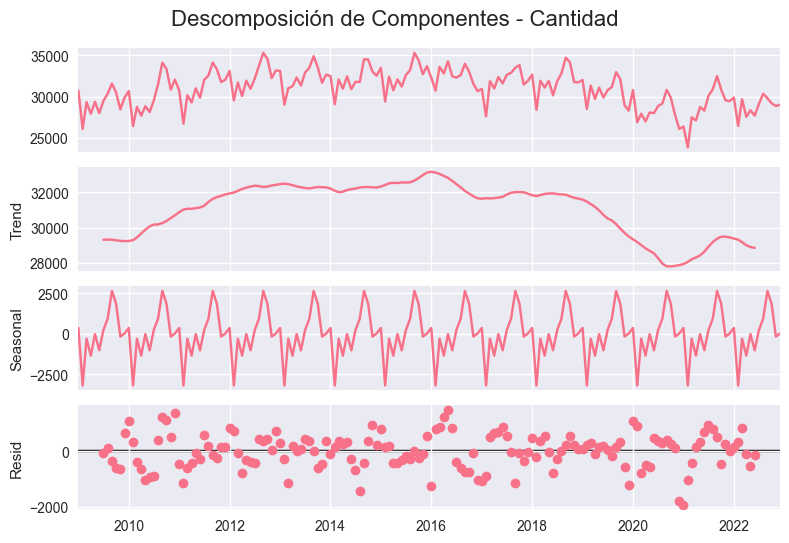

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

descomposicion = seasonal_decompose(df_nac, model='additive', period=12)
plt.figure(figsize=(14, 10))
descomposicion.plot()
plt.suptitle('Descomposición de Componentes - Cantidad', fontsize=16)
plt.tight_layout()
plt.show()

SI tiene tendencia y tambien tiene estacionalidad. Ademas se puede observar estacionariedad no tiene ni en varianza ni en media , pero si llega a acercarse bastante

# Analisis de Componentes

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

def analizar_series_combustibles(df, columnas_deseadas, ventana_varianza=12):
    """
    Función para analizar varianza y estacionariedad de series temporales de combustibles
      debes pasarle el df que es la serie con index fecha y las columnas deseadas
    """
    
    # Configurar estilo de gráficos
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    def calcular_varianza_movil(serie, ventana=12):
        """Calcula la varianza móvil de una serie temporal"""
        return serie.rolling(window=ventana, center=True).var()

    def prueba_adf(serie, nombre_serie):
        """Realiza la prueba Augmented Dickey-Fuller"""
        resultado = adfuller(serie.dropna(), autolag='AIC')
        
        print(f"\n{'='*50}")
        print(f"PRUEBA AUGMENTED DICKEY-FULLER - {nombre_serie.upper()}")
        print(f"{'='*50}")
        print(f"Estadístico ADF: {resultado[0]:.4f}")
        print(f"P-valor: {resultado[1]:.4f}")
        print(f"Número de lags utilizados: {resultado[2]}")
        print(f"Número de observaciones: {resultado[3]}")
        print(f"Valores críticos:")
        for clave, valor in resultado[4].items():
            print(f"\t{clave}: {valor:.4f}")
        
        # Interpretación
        if resultado[1] <= 0.05:
            print(f"\n✅ RESULTADO: La serie ES ESTACIONARIA (p-valor = {resultado[1]:.4f} ≤ 0.05)")
            print("   Se rechaza la hipótesis nula de raíz unitaria")
            es_estacionaria = True
        else:
            print(f"\n❌ RESULTADO: La serie NO ES ESTACIONARIA (p-valor = {resultado[1]:.4f} > 0.05)")
            print("   No se puede rechazar la hipótesis nula de raíz unitaria")
            es_estacionaria = False
        
        return resultado, es_estacionaria

    def prueba_kpss(serie, nombre_serie):
        """Realiza la prueba KPSS como complemento"""
        resultado = kpss(serie.dropna(), regression='c', nlags='auto')
        
        print(f"\n{'='*50}")
        print(f"PRUEBA KPSS - {nombre_serie.upper()}")
        print(f"{'='*50}")
        print(f"Estadístico KPSS: {resultado[0]:.4f}")
        print(f"P-valor: {resultado[1]:.4f}")
        print(f"Número de lags: {resultado[2]}")
        print(f"Valores críticos:")
        for clave, valor in resultado[3].items():
            print(f"\t{clave}: {valor:.4f}")
        
        # Interpretación (KPSS tiene hipótesis nula opuesta a ADF)
        if resultado[1] <= 0.05:
            print(f"\n❌ RESULTADO KPSS: La serie NO ES ESTACIONARIA (p-valor = {resultado[1]:.4f} ≤ 0.05)")
            print("   Se rechaza la hipótesis nula de estacionariedad")
            es_estacionaria = False
        else:
            print(f"\n✅ RESULTADO KPSS: La serie ES ESTACIONARIA (p-valor = {resultado[1]:.4f} > 0.05)")
            print("   No se puede rechazar la hipótesis nula de estacionariedad")
            es_estacionaria = True
        
        return resultado, es_estacionaria

    # Convertir a numérico cada columna
    df_work = df.copy()
    for col in columnas_deseadas:
        df_work[col] = pd.to_numeric(df_work[col], errors='coerce')
    
    # Diccionario para almacenar resultados
    resultados_pruebas = {}
    
    # Análisis para cada combustible
    for columna in columnas_deseadas:
        serie = df_work[columna].dropna()
        
        if len(serie) >= 12:  # Al menos 1 año de datos
            print(f"\n🔍 ANALIZANDO: {columna.upper()}")
            print("="*60)
            
            # Calcular varianza móvil
            varianza_movil = calcular_varianza_movil(serie, ventana=ventana_varianza)
            
            # GRÁFICO DE LA SERIE CON VARIANZA SUPERPUESTA
            fig, ax1 = plt.subplots(figsize=(15, 8))
            
            # Serie original en el eje izquierdo
            color_serie = 'tab:blue'
            ax1.set_xlabel('Fecha', fontsize=12)
            ax1.set_ylabel('Consumo', color=color_serie, fontsize=12)
            line1 = ax1.plot(serie.index, serie.values, linewidth=2, color=color_serie, 
                           label=f'{columna}', alpha=0.8)
            ax1.tick_params(axis='y', labelcolor=color_serie)
            ax1.grid(True, alpha=0.3)
            
            # Varianza móvil en el eje derecho
            ax2 = ax1.twinx()
            color_varianza = 'tab:red'
            ax2.set_ylabel('Varianza Móvil', color=color_varianza, fontsize=12)
            line2 = ax2.plot(varianza_movil.index, varianza_movil.values, 
                           linewidth=2, color=color_varianza, linestyle='--',
                           label=f'Varianza móvil ({ventana_varianza} períodos)', alpha=0.7)
            ax2.tick_params(axis='y', labelcolor=color_varianza)
            
            # Título y leyenda
            plt.title(f'Serie Temporal y Varianza Móvil - {columna}', 
                     fontsize=14, fontweight='bold', pad=20)
            
            # Combinar leyendas
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
            
            plt.tight_layout()
            plt.show()
            
            # Gráfico adicional solo de la varianza para mejor análisis
            plt.figure(figsize=(15, 5))
            plt.plot(varianza_movil.index, varianza_movil.values, 
                    linewidth=2, color='red', label=f'Varianza móvil ({ventana_varianza} períodos)')
            plt.fill_between(varianza_movil.index, varianza_movil.values, alpha=0.3, color='red')
            plt.title(f'Evolución de la Varianza Móvil - {columna}', fontsize=14, fontweight='bold')
            plt.ylabel('Varianza')
            plt.xlabel('Fecha')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # PRUEBAS DE ESTACIONARIEDAD
            resultado_adf, est_adf = prueba_adf(serie, columna)
            resultado_kpss, est_kpss = prueba_kpss(serie, columna)
            
            # Guardar resultados
            resultados_pruebas[columna] = {
                'ADF_estadistico': resultado_adf[0],
                'ADF_pvalor': resultado_adf[1],
                'ADF_estacionaria': est_adf,
                'KPSS_estadistico': resultado_kpss[0],
                'KPSS_pvalor': resultado_kpss[1],
                'KPSS_estacionaria': est_kpss,
                'Consenso_estacionaria': est_adf and est_kpss
            }
            
            print(f"\n{'='*60}")
            
        else:
            print(f"[❗] No hay suficientes datos para analizar la serie: {columna}")
            resultados_pruebas[columna] = None

    # RESUMEN ESTADÍSTICO DE TODAS LAS SERIES
    print("\n" + "="*80)
    print("RESUMEN ESTADÍSTICO - TODAS LAS SERIES")
    print("="*80)

    resumen_estadistico = pd.DataFrame()
    for columna in columnas_deseadas:
        serie = df_work[columna].dropna()
        if len(serie) > 0:
            stats = {
                'Media': serie.mean(),
                'Mediana': serie.median(),
                'Desv. Estándar': serie.std(),
                'Varianza': serie.var(),
                'CV (%)': (serie.std() / serie.mean()) * 100,  # Coeficiente de variación
                'Min': serie.min(),
                'Max': serie.max(),
                'Observaciones': len(serie)
            }
            resumen_estadistico[columna] = stats

    print(resumen_estadistico.round(4))
    
    # RESUMEN DE PRUEBAS DE ESTACIONARIEDAD
    print("\n" + "="*80)
    print("RESUMEN DE PRUEBAS DE ESTACIONARIEDAD")
    print("="*80)
    
    resumen_estacionariedad = pd.DataFrame()
    for columna, resultados in resultados_pruebas.items():
        if resultados is not None:
            resumen_estacionariedad[columna] = {
                'ADF p-valor': resultados['ADF_pvalor'],
                'KPSS p-valor': resultados['KPSS_pvalor'],
                'ADF Estacionaria': '✅' if resultados['ADF_estacionaria'] else '❌',
                'KPSS Estacionaria': '✅' if resultados['KPSS_estacionaria'] else '❌',
                'Consenso': '✅' if resultados['Consenso_estacionaria'] else '❌'
            }
    
    if len(resumen_estacionariedad.columns) > 0:
        print(resumen_estacionariedad.T)
    
    return resultados_pruebas




🔍 ANALIZANDO: CANTIDAD


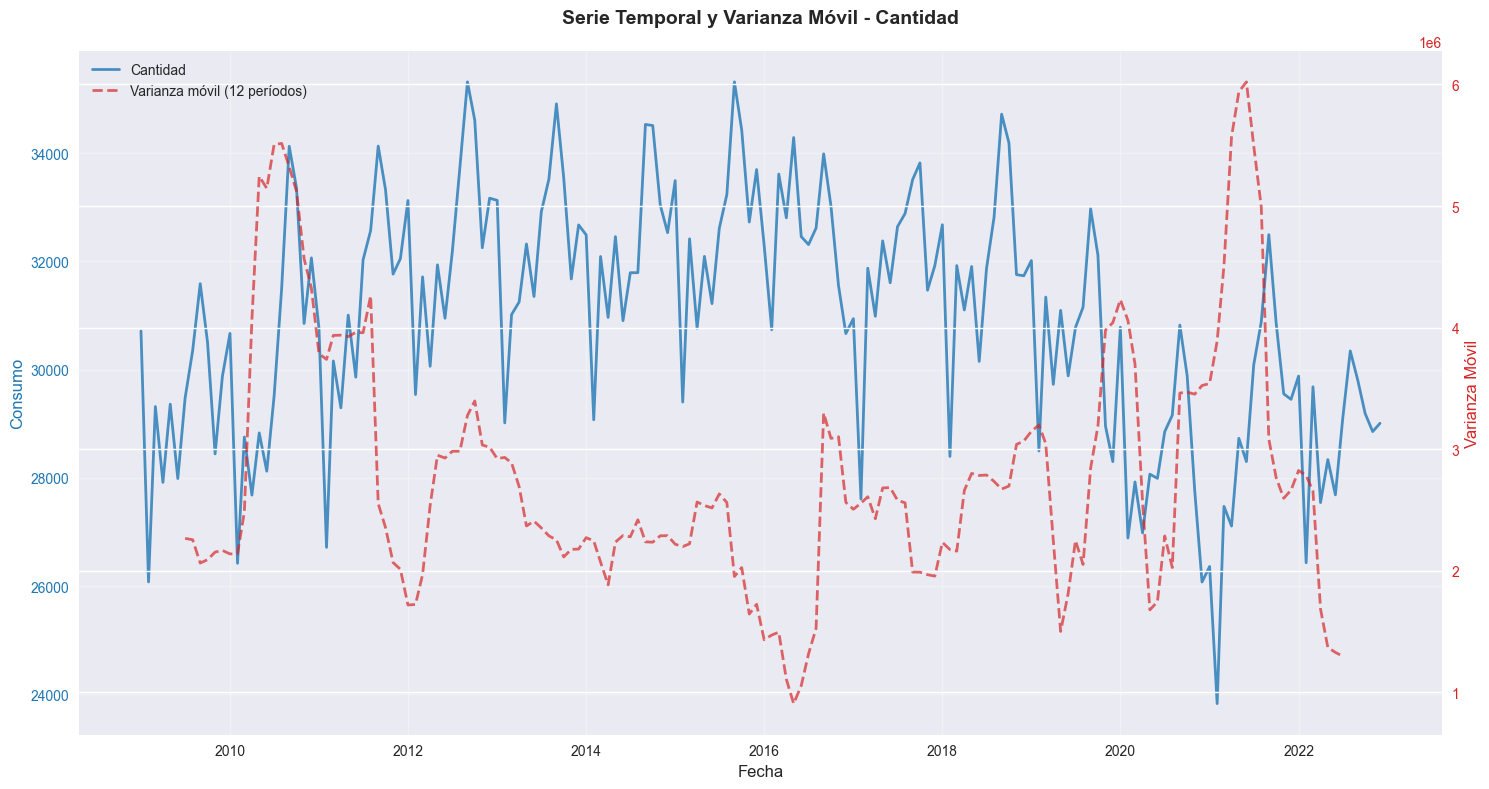

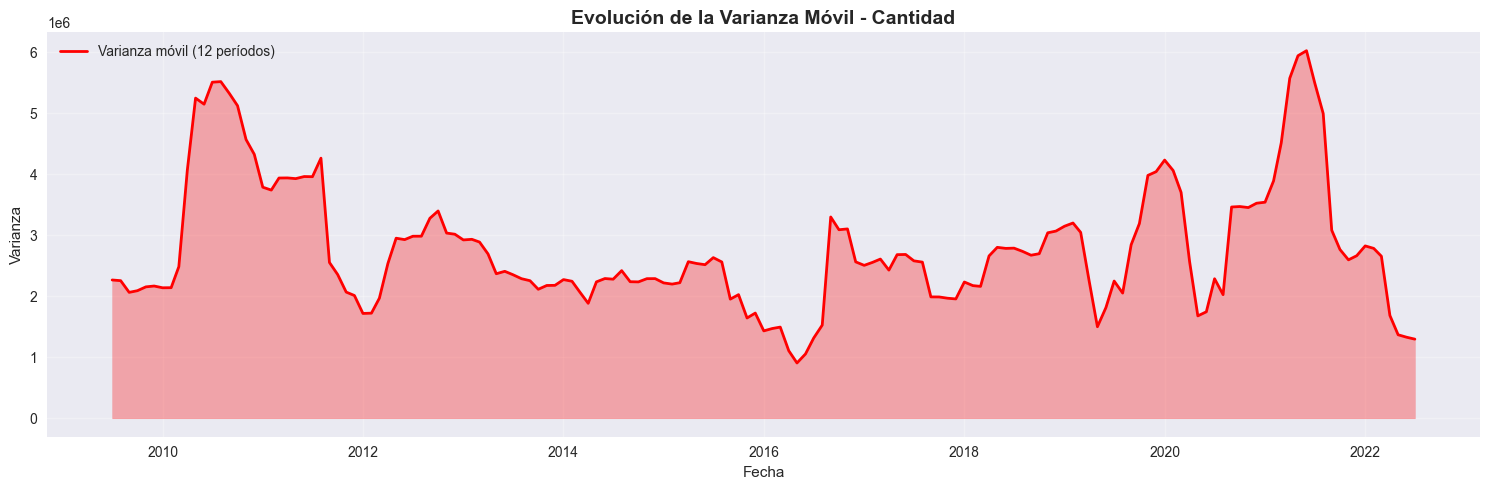


PRUEBA AUGMENTED DICKEY-FULLER - CANTIDAD
Estadístico ADF: -1.2764
P-valor: 0.6399
Número de lags utilizados: 12
Número de observaciones: 155
Valores críticos:
	1%: -3.4733
	5%: -2.8804
	10%: -2.5768

❌ RESULTADO: La serie NO ES ESTACIONARIA (p-valor = 0.6399 > 0.05)
   No se puede rechazar la hipótesis nula de raíz unitaria

PRUEBA KPSS - CANTIDAD
Estadístico KPSS: 0.5569
P-valor: 0.0288
Número de lags: 8
Valores críticos:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390

❌ RESULTADO KPSS: La serie NO ES ESTACIONARIA (p-valor = 0.0288 ≤ 0.05)
   Se rechaza la hipótesis nula de estacionariedad


RESUMEN ESTADÍSTICO - TODAS LAS SERIES
                    Cantidad
Media           3.092378e+04
Mediana         3.110050e+04
Desv. Estándar  2.212838e+03
Varianza        4.896650e+06
CV (%)          7.155800e+00
Min             2.382800e+04
Max             3.532000e+04
Observaciones   1.680000e+02

RESUMEN DE PRUEBAS DE ESTACIONARIEDAD
         ADF p-valor KPSS p-valor ADF Estacionaria KPSS

In [37]:
resultados = analizar_series_combustibles(
    df=df_nac, 
    columnas_deseadas=['Cantidad'],
    ventana_varianza=12
)

### Transformacion de Serie

Ahora la vamos a transformar con el siguiente codigo

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

def transformacion_logaritmica(df, columnas_deseadas, ventana_varianza=12):
   
    
    def calcular_varianza_movil(serie, ventana=12):
        """Calcula la varianza móvil de una serie temporal"""
        return serie.rolling(window=ventana, center=True).var()
    
   
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
   
    df_log = df.copy()
    
    for columna in columnas_deseadas:
        serie_original = df[columna].dropna()
        
        if len(serie_original) >= 12:
            print(f"\n🔄 TRANSFORMACIÓN LOGARÍTMICA: {columna.upper()}")
            print("="*70)
            
            # Verificar que no hay valores negativos o cero
            if (serie_original <= 0).any():
                print(f"⚠️  ADVERTENCIA: La serie {columna} tiene valores ≤ 0")
                print("   Aplicando corrección: ln(x + 1) en lugar de ln(x)")
                serie_log = np.log1p(serie_original)  # ln(x + 1)
                df_log[columna] = serie_log
            else:
                serie_log = np.log(serie_original)
                df_log[columna] = serie_log
            
            # Calcular varianzas móviles
            var_original = calcular_varianza_movil(serie_original, ventana_varianza)
            var_log = calcular_varianza_movil(serie_log, ventana_varianza)
            
            # GRÁFICO COMPARATIVO: ANTES Y DESPUÉS
            fig, axes = plt.subplots(2, 2, figsize=(16, 10))
            
            # Serie original
            axes[0, 0].plot(serie_original.index, serie_original.values, 
                           linewidth=2, color='blue', label='Serie Original')
            axes[0, 0].set_title(f'Serie Original - {columna}', fontweight='bold')
            axes[0, 0].set_ylabel('Valor')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)
            
            # Serie transformada
            axes[0, 1].plot(serie_log.index, serie_log.values, 
                           linewidth=2, color='green', label='Serie Log-transformada')
            axes[0, 1].set_title(f'Serie Log-transformada - {columna}', fontweight='bold')
            axes[0, 1].set_ylabel('ln(Valor)')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
            
            # Varianza original
            axes[1, 0].plot(var_original.index, var_original.values, 
                           linewidth=2, color='red', label=f'Varianza Original (ventana={ventana_varianza})')
            axes[1, 0].fill_between(var_original.index, var_original.values, alpha=0.3, color='red')
            axes[1, 0].set_title(f'Varianza Móvil Original - {columna}', fontweight='bold')
            axes[1, 0].set_ylabel('Varianza')
            axes[1, 0].set_xlabel('Fecha')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
            
            # Varianza transformada
            axes[1, 1].plot(var_log.index, var_log.values, 
                           linewidth=2, color='orange', label=f'Varianza Log-transformada (ventana={ventana_varianza})')
            axes[1, 1].fill_between(var_log.index, var_log.values, alpha=0.3, color='orange')
            axes[1, 1].set_title(f'Varianza Móvil Log-transformada - {columna}', fontweight='bold')
            axes[1, 1].set_ylabel('Varianza')
            axes[1, 1].set_xlabel('Fecha')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
            
            plt.suptitle(f'Comparación: Original vs Log-transformada - {columna}', 
                        fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            # ESTADÍSTICAS COMPARATIVAS
            print(f"\n📊 ESTADÍSTICAS COMPARATIVAS:")
            print(f"{'Métrica':<25} {'Original':<15} {'Log-transformada':<15} {'Mejora':<10}")
            print("-" * 70)
            
            cv_original = (serie_original.std() / serie_original.mean()) * 100
            cv_log = (serie_log.std() / serie_log.mean()) * 100
            mejora_cv = ((cv_original - cv_log) / cv_original) * 100
            
            var_original_media = var_original.mean()
            var_log_media = var_log.mean()
            mejora_var = ((var_original_media - var_log_media) / var_original_media) * 100
            
            print(f"{'Coef. Variación (%)':<25} {cv_original:<15.4f} {cv_log:<15.4f} {mejora_cv:<10.2f}%")
            print(f"{'Varianza Media':<25} {var_original_media:<15.4f} {var_log_media:<15.4f} {mejora_var:<10.2f}%")
            print(f"{'Desv. Estándar':<25} {serie_original.std():<15.4f} {serie_log.std():<15.4f}")
            
            # EVALUACIÓN DE LA TRANSFORMACIÓN
            if mejora_cv > 0:
                print(f"\n✅ RESULTADO: La transformación logarítmica MEJORÓ la estabilidad de varianza")
                print(f"   Reducción del coeficiente de variación: {mejora_cv:.2f}%")
            else:
                print(f"\n⚠️  RESULTADO: La transformación logarítmica NO mejoró significativamente la varianza")
                print(f"   Cambio en coeficiente de variación: {mejora_cv:.2f}%")
        
        else:
            print(f"[❗] No hay suficientes datos para transformar la serie: {columna}")
    
    return df_log


def diferenciacion_series_completa(df, columnas_deseadas, max_diferencias=3, retornar_dataframe=True):
    
    
    def prueba_adf_simple(serie):
        """Versión simplificada de la prueba ADF"""
        try:
            resultado = adfuller(serie.dropna(), autolag='AIC')
            return resultado[1], resultado[1] <= 0.05
        except:
            return 1.0, False
    
    def prueba_kpss_simple(serie):
        """Versión simplificada de la prueba KPSS"""
        try:
            resultado = kpss(serie.dropna(), regression='c', nlags='auto')
            return resultado[1], resultado[1] > 0.05
        except:
            return 0.0, False
    
    # Configurar estilo de gráficos
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    resultados_diferenciacion = {}
    df_estacionario = df.copy()  # DataFrame final con series estacionarias
    
    for columna in columnas_deseadas:
        serie_original = df[columna].dropna()
        
        if len(serie_original) >= 12:
            print(f"\n🔍 DIFERENCIACIÓN ITERATIVA: {columna.upper()}")
            print("="*70)
            
            series_diferenciadas = {'0': serie_original}
            resultados_pruebas = {}
            mejor_orden = '0'  # Por defecto, serie original
            
            # Probar serie original
            adf_pval, adf_est = prueba_adf_simple(serie_original)
            kpss_pval, kpss_est = prueba_kpss_simple(serie_original)
            
            resultados_pruebas['0'] = {
                'adf_pvalor': adf_pval,
                'adf_estacionaria': adf_est,
                'kpss_pvalor': kpss_pval,
                'kpss_estacionaria': kpss_est,
                'consenso': adf_est and kpss_est
            }
            
            # Si ya es estacionaria, no diferenciamos
            if resultados_pruebas['0']['consenso']:
                mejor_orden = '0'
            else:
                # Aplicar diferenciaciones sucesivas
                serie_actual = serie_original.copy()
                
                for d in range(1, max_diferencias + 1):
                    serie_actual = serie_actual.diff().dropna()
                    
                    if len(serie_actual) < 10:
                        break
                    
                    series_diferenciadas[str(d)] = serie_actual.copy()
                    
                    # Probar estacionariedad
                    adf_pval, adf_est = prueba_adf_simple(serie_actual)
                    kpss_pval, kpss_est = prueba_kpss_simple(serie_actual)
                    
                    resultados_pruebas[str(d)] = {
                        'adf_pvalor': adf_pval,
                        'adf_estacionaria': adf_est,
                        'kpss_pvalor': kpss_pval,
                        'kpss_estacionaria': kpss_est,
                        'consenso': adf_est and kpss_est
                    }
                    
                    # Si encontramos consenso, paramos
                    if resultados_pruebas[str(d)]['consenso']:
                        mejor_orden = str(d)
                        break
                
                # Si no hay consenso, elegir la mejor opción (menor p-valor ADF)
                if mejor_orden == '0' and not resultados_pruebas['0']['consenso']:
                    mejor_opcion = min(resultados_pruebas.items(), 
                                     key=lambda x: (not x[1]['adf_estacionaria'], x[1]['adf_pvalor']))
                    mejor_orden = mejor_opcion[0]
            
            # VISUALIZACIÓN
            n_series = len(series_diferenciadas)
            fig, axes = plt.subplots(n_series, 1, figsize=(15, 4 * n_series))
            
            if n_series == 1:
                axes = [axes]
            
            for i, (orden, serie) in enumerate(series_diferenciadas.items()):
                resultado = resultados_pruebas[orden]
                
                # Destacar la serie seleccionada
                if orden == mejor_orden:
                    color = 'darkgreen'
                    linewidth = 3
                    titulo_extra = " 🎯 SELECCIONADA"
                elif resultado['consenso']:
                    color = 'green'
                    linewidth = 2
                    titulo_extra = " ✅ ESTACIONARIA"
                else:
                    color = 'lightcoral'
                    linewidth = 1
                    titulo_extra = " ❌ NO ESTACIONARIA"
                
                axes[i].plot(serie.index, serie.values, linewidth=linewidth, color=color)
                
                if orden == '0':
                    titulo = f'Serie Original - {columna}{titulo_extra}'
                else:
                    titulo = f'Serie con {orden} diferenciación(es) - {columna}{titulo_extra}'
                
                axes[i].set_title(titulo, fontweight='bold')
                axes[i].set_ylabel('Valor')
                axes[i].grid(True, alpha=0.3)
                
                info_text = f"ADF p-val: {resultado['adf_pvalor']:.4f} | KPSS p-val: {resultado['kpss_pvalor']:.4f}"
                axes[i].text(0.02, 0.98, info_text, transform=axes[i].transAxes, 
                           fontsize=10, verticalalignment='top', 
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            axes[-1].set_xlabel('Fecha')
            plt.tight_layout()
            plt.show()
            
            # TABLA RESUMEN
            print(f"\n📋 RESUMEN DE DIFERENCIACIONES:")
            print(f"{'Orden':<8} {'ADF p-val':<12} {'ADF Est.':<10} {'KPSS p-val':<12} {'KPSS Est.':<10} {'Consenso':<10} {'Selec.':<8}")
            print("-" * 80)
            
            for orden, resultado in resultados_pruebas.items():
                adf_symbol = '✅' if resultado['adf_estacionaria'] else '❌'
                kpss_symbol = '✅' if resultado['kpss_estacionaria'] else '❌'
                consenso_symbol = '✅' if resultado['consenso'] else '❌'
                seleccionada = '🎯' if orden == mejor_orden else ''
                
                print(f"{orden:<8} {resultado['adf_pvalor']:<12.4f} {adf_symbol:<10} "
                      f"{resultado['kpss_pvalor']:<12.4f} {kpss_symbol:<10} {consenso_symbol:<10} {seleccionada:<8}")
            
            # APLICAR LA MEJOR TRANSFORMACIÓN AL DATAFRAME FINAL
            serie_seleccionada = series_diferenciadas[mejor_orden]
            
            # Alinear índices (la diferenciación puede cambiar el tamaño)
            df_estacionario.loc[serie_seleccionada.index, columna] = serie_seleccionada
            
            print(f"\n💡 RESULTADO FINAL:")
            if mejor_orden == '0':
                print(f"   ✅ Serie {columna}: mantenida original (ya estacionaria)")
            else:
                print(f"   🔄 Serie {columna}: aplicadas {mejor_orden} diferenciación(es)")
                print(f"   📉 Datos perdidos por diferenciación: {len(serie_original) - len(serie_seleccionada)}")
            
            resultados_diferenciacion[columna] = {
                'series': series_diferenciadas,
                'pruebas': resultados_pruebas,
                'mejor_orden': mejor_orden,
                'serie_final': serie_seleccionada
            }
        
        else:
            print(f"[❗] No hay suficientes datos para diferenciar la serie: {columna}")
    
    # Limpiar el DataFrame final (eliminar NaN introducidos por diferenciación)
    if retornar_dataframe:
        df_estacionario = df_estacionario.dropna()
        print(f"\n📊 DATAFRAME FINAL:")
        print(f"   Forma original: {df.shape}")
        print(f"   Forma final: {df_estacionario.shape}")
        print(f"   Columnas procesadas: {columnas_deseadas}")
        
        return df_estacionario, resultados_diferenciacion
    else:
        return resultados_diferenciacion


def pipeline_completo_estacionalizacion(df, columnas_deseadas, aplicar_log=True, 
                                       ventana_varianza=12, max_diferencias=3):
    
    
    print("🚀 INICIANDO PIPELINE COMPLETO DE ESTACIONARIZACIÓN")
    print("="*80)
    
    if aplicar_log:
        print("\n📍 PASO 1: TRANSFORMACIÓN LOGARÍTMICA")
        df_log = transformacion_logaritmica(df, columnas_deseadas, ventana_varianza)
    else:
        print("\n📍 PASO 1: SALTANDO TRANSFORMACIÓN LOGARÍTMICA")
        df_log = df.copy()
    
    print("\n📍 PASO 2: DIFERENCIACIÓN PARA ESTACIONARIEDAD")
    df_final, resultados_diff = diferenciacion_series_completa(
        df_log, columnas_deseadas, max_diferencias, retornar_dataframe=True
    )
    
    print("\n🎉 PIPELINE COMPLETADO")
    print(f"   DataFrame final: {df_final.shape}")
    print(f"   Series procesadas: {len(columnas_deseadas)}")
    
    return df_final, df_log if aplicar_log else None, resultados_diff






def verificar_estacionariedad_completa(df, columnas, ventana_varianza=12, mostrar_graficos=True):    
    def prueba_ljung_box_residuos(serie, lags=10):
        """Prueba Ljung-Box en residuos al cuadrado para detectar heterocedasticidad"""
        try:
            from statsmodels.stats.diagnostic import acorr_ljungbox
            residuos = serie - serie.mean()
            residuos_cuadrados = residuos ** 2
            resultado = acorr_ljungbox(residuos_cuadrados, lags=lags, return_df=True)
            p_valor = resultado['lb_pvalue'].iloc[-1]  # Último lag
            return p_valor, p_valor > 0.05  # True = varianza constante
        except:
            return np.nan, False
    
    def prueba_arch_simple(serie, lags=5):
        """Prueba ARCH para detectar heterocedasticidad"""
        try:
            # Calcular residuos (desviaciones de la media)
            residuos = serie - serie.mean()
            residuos_cuadrados = residuos ** 2
            
            # Crear DataFrame para la regresión
            data = pd.DataFrame({'y': residuos_cuadrados[lags:]})
            
            # Añadir lags de los residuos al cuadrado
            for i in range(1, lags + 1):
                data[f'lag_{i}'] = residuos_cuadrados.shift(i)[lags:]
            
            # Regresión simple
            X = data.iloc[:, 1:]  # Variables explicativas
            y = data.iloc[:, 0]   # Variable dependiente
            
            # Calcular R²
            correlacion = np.corrcoef(X.values.flatten(), 
                                    np.repeat(y.values, X.shape[1]))
            r_squared = correlacion[0, 1] ** 2 if not np.isnan(correlacion[0, 1]) else 0
            
            # Estadístico LM = n * R²
            n = len(y)
            lm_stat = n * r_squared
            
            # p-valor usando distribución chi-cuadrado
            p_valor = 1 - stats.chi2.cdf(lm_stat, lags)
            
            return p_valor, p_valor > 0.05  # True = no hay efectos ARCH
        except:
            return np.nan, False
    
    def calcular_varianza_movil(serie, ventana):
        """Calcular varianza móvil"""
        return serie.rolling(window=ventana, center=True).var()
    
    def prueba_estabilidad_varianza(serie, ventana=12):
        """Prueba simple de estabilidad de varianza"""
        try:
            var_movil = calcular_varianza_movil(serie, ventana).dropna()
            
            # Coeficiente de variación de las varianzas móviles
            cv_varianza = (var_movil.std() / var_movil.mean()) * 100
            
            # Criterio: CV < 50% indica varianza relativamente estable
            estable = cv_varianza < 50
            
            return cv_varianza, estable
        except:
            return np.nan, False
    
    print("🔍 VERIFICACIÓN COMPLETA DE ESTACIONARIEDAD")
    print("="*80)
    print("📊 Analizando: MEDIA + VARIANZA")
    print("-"*80)
    
    resultados = []
    
    for columna in columnas:
        if columna not in df.columns:
            print(f"⚠️ Columna '{columna}' no encontrada en el DataFrame")
            continue
            
        serie = df[columna].dropna()
        
        if len(serie) < 20:
            print(f"⚠️ Muy pocos datos en '{columna}' ({len(serie)} observaciones)")
            continue
            
        print(f"\n📈 ANÁLISIS: {columna.upper()}")
        print("-" * 50)
        
        # === PRUEBAS DE ESTACIONARIEDAD EN MEDIA ===
        try:
            adf_result = adfuller(serie, autolag='AIC')
            adf_pval = adf_result[1]
            adf_estacionaria = adf_pval <= 0.05
        except:
            adf_pval, adf_estacionaria = np.nan, False
            
        try:
            kpss_result = kpss(serie, regression='c', nlags='auto')
            kpss_pval = kpss_result[1]
            kpss_estacionaria = kpss_pval > 0.05
        except:
            kpss_pval, kpss_estacionaria = np.nan, False
        
        consenso_media = adf_estacionaria and kpss_estacionaria
        
        # === PRUEBAS DE ESTACIONARIEDAD EN VARIANZA ===
        cv_varianza, varianza_estable = prueba_estabilidad_varianza(serie, ventana_varianza)
        ljung_pval, ljung_estable = prueba_ljung_box_residuos(serie)
        arch_pval, arch_estable = prueba_arch_simple(serie)
        
        # Consenso en varianza: al menos 2 de 3 pruebas indican estabilidad
        consenso_varianza = sum([varianza_estable, ljung_estable, arch_estable]) >= 2
        
        # === RESULTADO GENERAL ===
        estacionaria_completa = consenso_media and consenso_varianza
        
        # Mostrar resultados
        print(f"MEDIA:")
        print(f"  ADF p-valor:        {adf_pval:.4f} {'✅' if adf_estacionaria else '❌'}")
        print(f"  KPSS p-valor:       {kpss_pval:.4f} {'✅' if kpss_estacionaria else '❌'}")
        print(f"  Consenso Media:     {'✅ ESTACIONARIA' if consenso_media else '❌ NO ESTACIONARIA'}")
        
        print(f"VARIANZA:")
        print(f"  CV Varianza:        {cv_varianza:.2f}% {'✅' if varianza_estable else '❌'}")
        print(f"  Ljung-Box p-val:    {ljung_pval:.4f} {'✅' if ljung_estable else '❌'}")
        print(f"  ARCH p-valor:       {arch_pval:.4f} {'✅' if arch_estable else '❌'}")
        print(f"  Consenso Varianza:  {'✅ ESTABLE' if consenso_varianza else '❌ INESTABLE'}")
        
        print(f"RESULTADO FINAL:      {'🎉 COMPLETAMENTE ESTACIONARIA' if estacionaria_completa else '⚠️ REQUIERE ATENCIÓN'}")
        
        # Guardar resultados
        resultados.append({
            'Serie': columna,
            'ADF_pval': adf_pval,
            'ADF_estacionaria': adf_estacionaria,
            'KPSS_pval': kpss_pval,
            'KPSS_estacionaria': kpss_estacionaria,
            'Consenso_Media': consenso_media,
            'CV_Varianza': cv_varianza,
            'Ljung_Box_pval': ljung_pval,
            'Ljung_Box_estable': ljung_estable,
            'ARCH_pval': arch_pval,
            'ARCH_estable': arch_estable,
            'Consenso_Varianza': consenso_varianza,
            'Estacionaria_Completa': estacionaria_completa
        })
        
        # === GRÁFICOS DE DIAGNÓSTICO ===
        if mostrar_graficos:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Serie temporal
            axes[0, 0].plot(serie.index, serie.values, linewidth=2, color='blue')
            axes[0, 0].set_title(f'Serie Temporal - {columna}', fontweight='bold')
            axes[0, 0].set_ylabel('Valor')
            axes[0, 0].grid(True, alpha=0.3)
            
            # Varianza móvil
            var_movil = calcular_varianza_movil(serie, ventana_varianza)
            axes[0, 1].plot(var_movil.index, var_movil.values, linewidth=2, color='red')
            axes[0, 1].fill_between(var_movil.index, var_movil.values, alpha=0.3, color='red')
            axes[0, 1].set_title(f'Varianza Móvil (ventana={ventana_varianza})', fontweight='bold')
            axes[0, 1].set_ylabel('Varianza')
            axes[0, 1].grid(True, alpha=0.3)
            
            # Histograma
            axes[1, 0].hist(serie.values, bins=30, alpha=0.7, color='green', edgecolor='black')
            axes[1, 0].set_title('Distribución de Valores', fontweight='bold')
            axes[1, 0].set_xlabel('Valor')
            axes[1, 0].set_ylabel('Frecuencia')
            axes[1, 0].grid(True, alpha=0.3)
            
            # Residuos al cuadrado (proxy para heterocedasticidad)
            residuos = serie - serie.mean()
            residuos_cuadrados = residuos ** 2
            axes[1, 1].plot(residuos_cuadrados.index, residuos_cuadrados.values, 
                          linewidth=1, color='purple', alpha=0.7)
            axes[1, 1].set_title('Residuos al Cuadrado', fontweight='bold')
            axes[1, 1].set_xlabel('Fecha')
            axes[1, 1].set_ylabel('Residuo²')
            axes[1, 1].grid(True, alpha=0.3)
            
            # Color de fondo según resultado
            color_fondo = 'lightgreen' if estacionaria_completa else 'lightcoral'
            fig.patch.set_facecolor(color_fondo)
            fig.patch.set_alpha(0.1)
            
            plt.suptitle(f'Diagnóstico Completo - {columna}\n'
                        f'{"🎉 COMPLETAMENTE ESTACIONARIA" if estacionaria_completa else "⚠️ REQUIERE ATENCIÓN"}',
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    # === TABLA RESUMEN ===
    df_resultados = pd.DataFrame(resultados)
    
    print(f"\n📋 RESUMEN GENERAL")
    print("="*100)
    
    if len(df_resultados) > 0:
        print(f"{'Serie':<25} {'Media':<8} {'Varianza':<10} {'Completa':<10} {'Estado'}")
        print("-"*100)
        
        for _, fila in df_resultados.iterrows():
            media_sym = '✅' if fila['Consenso_Media'] else '❌'
            varianza_sym = '✅' if fila['Consenso_Varianza'] else '❌'
            completa_sym = '✅' if fila['Estacionaria_Completa'] else '❌'
            estado = 'LISTA' if fila['Estacionaria_Completa'] else 'REVISAR'
            
            print(f"{fila['Serie']:<25} {media_sym:<8} {varianza_sym:<10} {completa_sym:<10} {estado}")
        
        # Estadísticas finales
        total_series = len(df_resultados)
        series_completas = df_resultados['Estacionaria_Completa'].sum()
        series_media_ok = df_resultados['Consenso_Media'].sum()
        series_varianza_ok = df_resultados['Consenso_Varianza'].sum()
        
        print(f"\n📊 ESTADÍSTICAS FINALES:")
        print(f"   Series analizadas:           {total_series}")
        print(f"   Estacionarias en media:      {series_media_ok}/{total_series} ({series_media_ok/total_series*100:.1f}%)")
        print(f"   Estables en varianza:        {series_varianza_ok}/{total_series} ({series_varianza_ok/total_series*100:.1f}%)")
        print(f"   Completamente estacionarias: {series_completas}/{total_series} ({series_completas/total_series*100:.1f}%)")
        
        if series_completas == total_series:
            print(f"\n🎉 ¡EXCELENTE! Todas las series están completamente estacionarias")
        elif series_completas > 0:
            print(f"\n⚠️ {total_series - series_completas} serie(s) requieren atención adicional")
        else:
            print(f"\n❌ Ninguna serie está completamente estacionaria - revisar transformaciones")
    
    return df_resultados



def interpretar_resultados_estacionariedad(df_resultados):

    
    print("\n💡 RECOMENDACIONES ESPECÍFICAS:")
    print("="*60)
    
    for _, fila in df_resultados.iterrows():
        serie = fila['Serie']
        print(f"\n📈 {serie.upper()}:")
        
        if fila['Estacionaria_Completa']:
            print("   ✅ Lista para modelado (ARIMA, VAR, etc.)")
        else:
            if not fila['Consenso_Media']:
                if not fila['ADF_estacionaria']:
                    print("   🔄 Considerar diferenciación adicional")
                if not fila['KPSS_estacionaria']:
                    print("   📉 Posible tendencia - revisar diferenciación")
            
            if not fila['Consenso_Varianza']:
                if fila['CV_Varianza'] > 50:
                    print("   📊 Varianza inestable - considerar transformación logarítmica")
                if not fila['ARCH_estable']:
                    print("   📈 Efectos ARCH detectados - considerar modelos GARCH")
                if not fila['Ljung_Box_estable']:
                    print("   🔍 Heterocedasticidad detectada - revisar transformaciones")






Como no tenemos estacionariedad ni en media ni en varianza con el codigo anterior lo usaremos para aplicar


🔄 TRANSFORMACIÓN LOGARÍTMICA: CANTIDAD


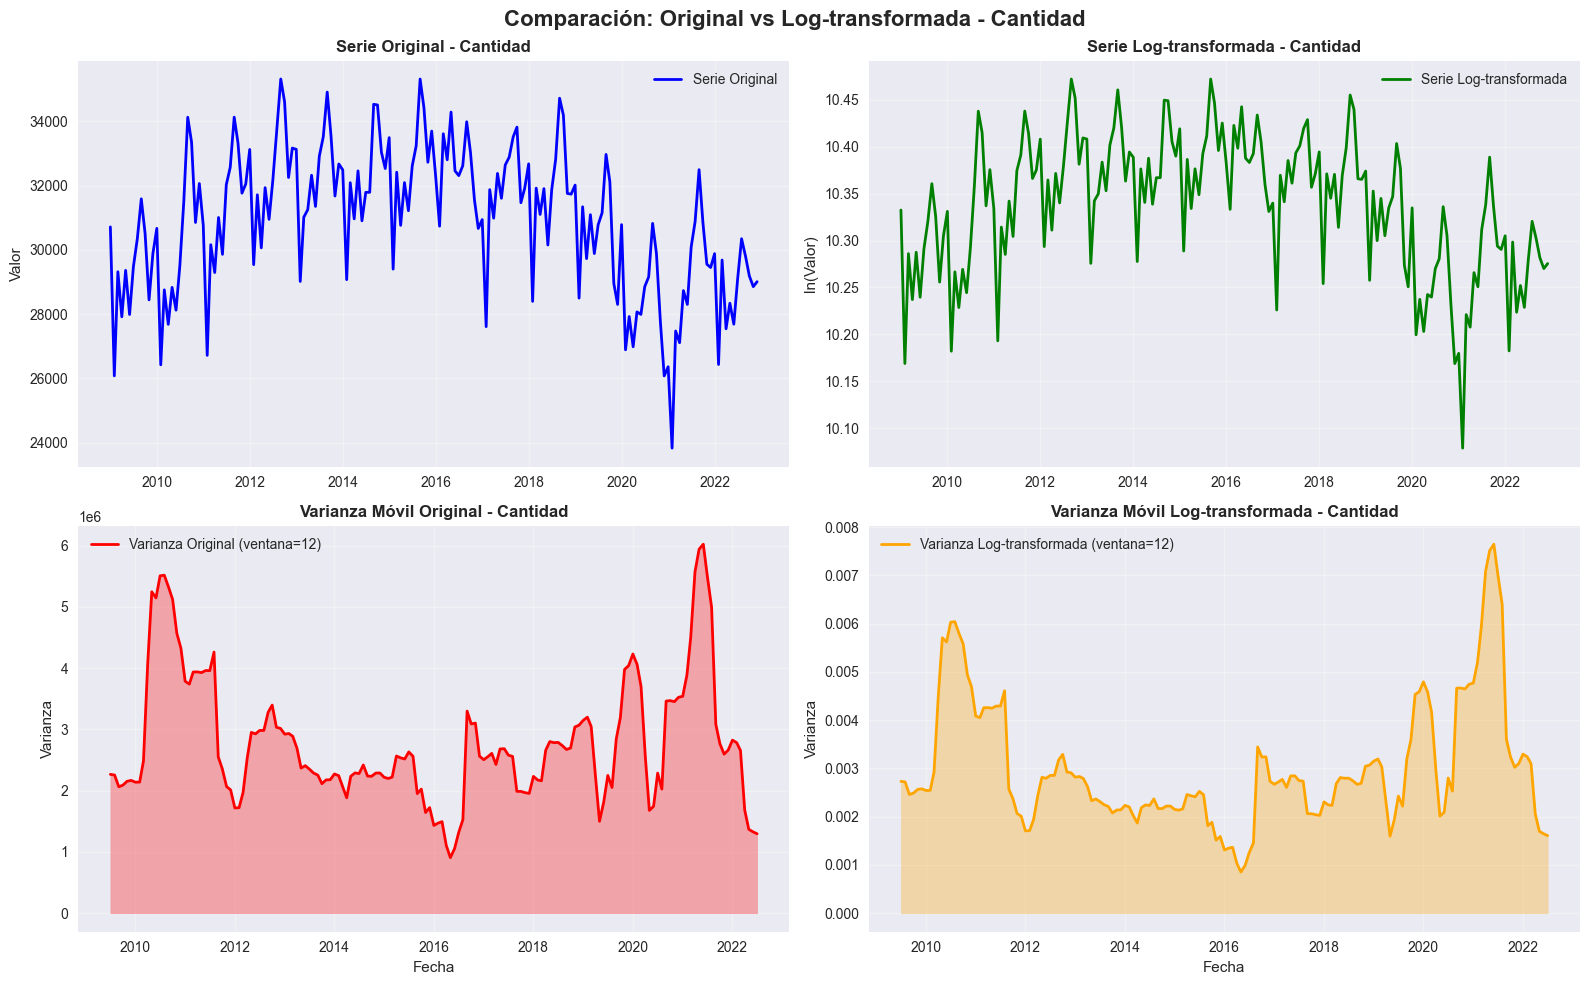


📊 ESTADÍSTICAS COMPARATIVAS:
Métrica                   Original        Log-transformada Mejora    
----------------------------------------------------------------------
Coef. Variación (%)       7.1558          0.7060          90.13     %
Varianza Media            2789061.1125    0.0030          100.00    %
Desv. Estándar            2212.8376       0.0730         

✅ RESULTADO: La transformación logarítmica MEJORÓ la estabilidad de varianza
   Reducción del coeficiente de variación: 90.13%
🚀 INICIANDO PIPELINE COMPLETO DE ESTACIONARIZACIÓN

📍 PASO 1: TRANSFORMACIÓN LOGARÍTMICA

🔄 TRANSFORMACIÓN LOGARÍTMICA: CANTIDAD


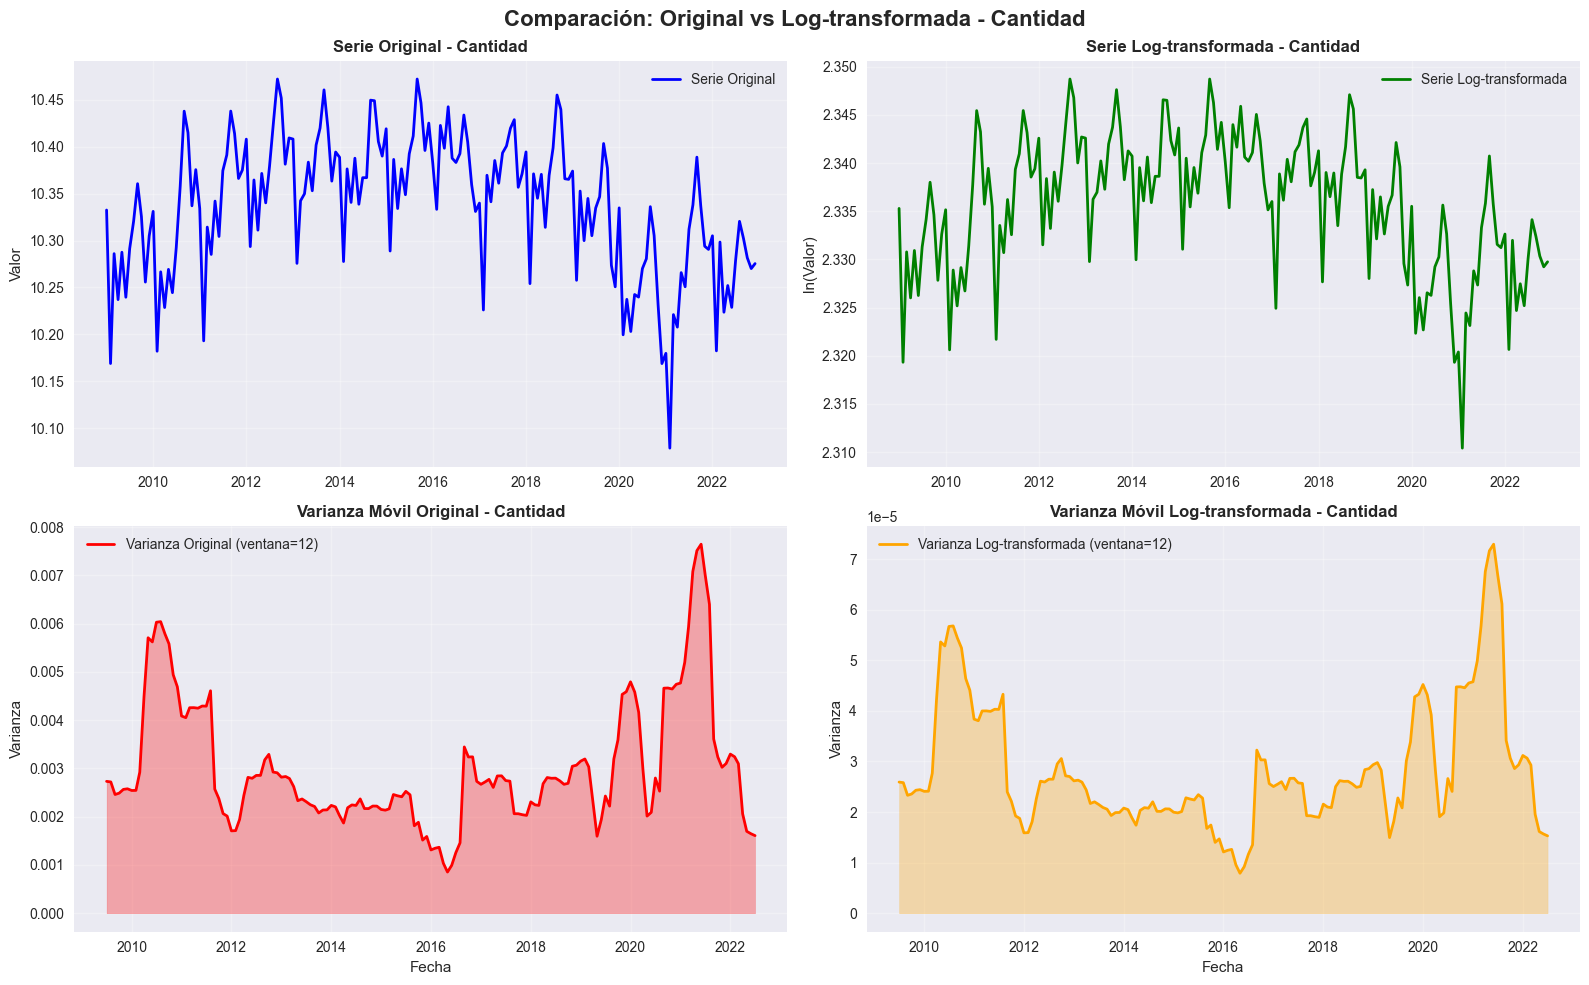


📊 ESTADÍSTICAS COMPARATIVAS:
Métrica                   Original        Log-transformada Mejora    
----------------------------------------------------------------------
Coef. Variación (%)       0.7060          0.3029          57.10     %
Varianza Media            0.0030          0.0000          99.06     %
Desv. Estándar            0.0730          0.0071         

✅ RESULTADO: La transformación logarítmica MEJORÓ la estabilidad de varianza
   Reducción del coeficiente de variación: 57.10%

📍 PASO 2: DIFERENCIACIÓN PARA ESTACIONARIEDAD

🔍 DIFERENCIACIÓN ITERATIVA: CANTIDAD


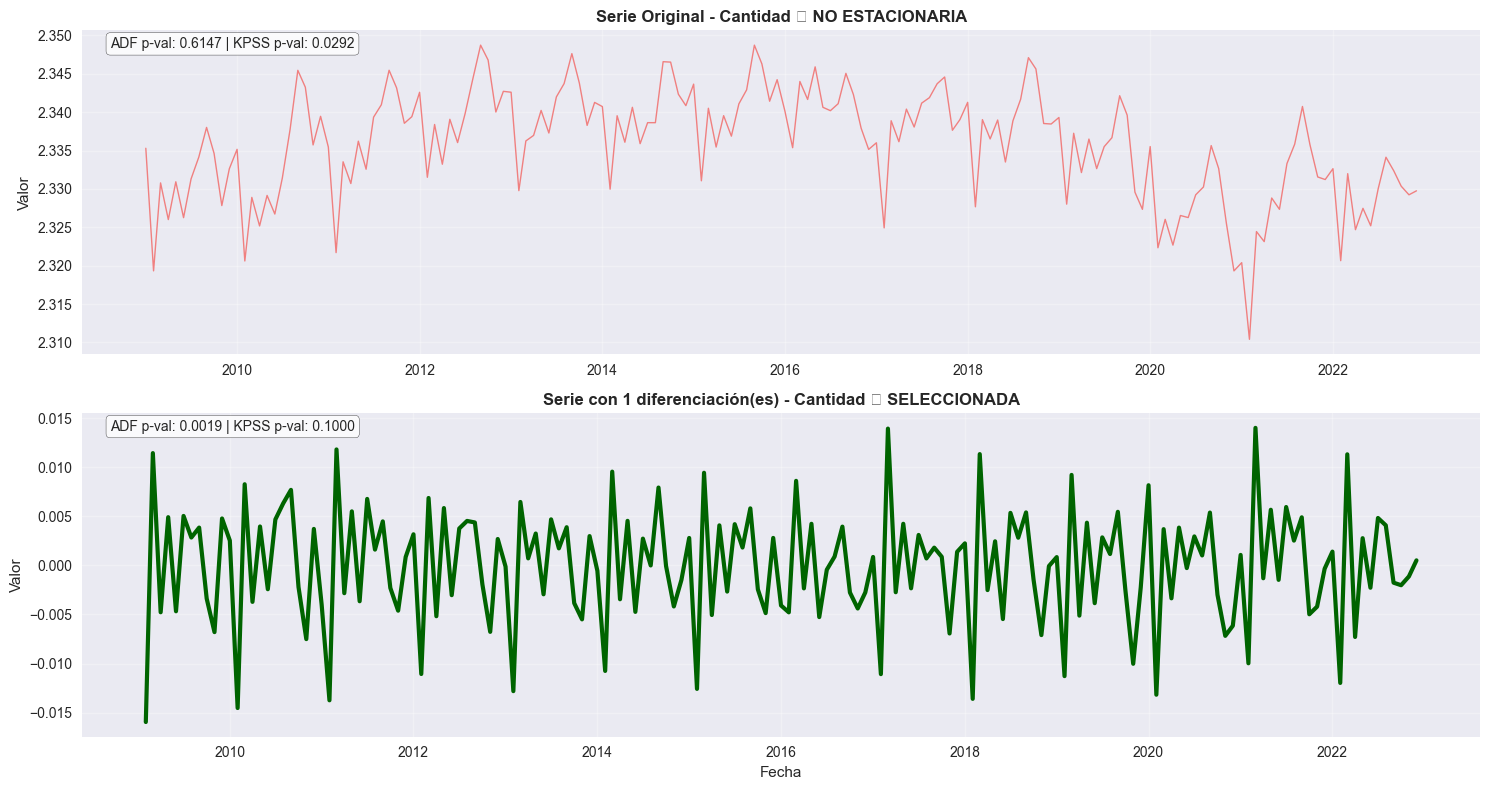


📋 RESUMEN DE DIFERENCIACIONES:
Orden    ADF p-val    ADF Est.   KPSS p-val   KPSS Est.  Consenso   Selec.  
--------------------------------------------------------------------------------
0        0.6147       ❌          0.0292       ❌          ❌                  
1        0.0019       ✅          0.1000       ✅          ✅          🎯       

💡 RESULTADO FINAL:
   🔄 Serie Cantidad: aplicadas 1 diferenciación(es)
   📉 Datos perdidos por diferenciación: 1

📊 DATAFRAME FINAL:
   Forma original: (168, 1)
   Forma final: (168, 1)
   Columnas procesadas: ['Cantidad']

🎉 PIPELINE COMPLETADO
   DataFrame final: (168, 1)
   Series procesadas: 1


In [40]:

df_log_nac = transformacion_logaritmica(
    df=df_nac,
    columnas_deseadas=['Cantidad']
)



df_final_nac, _, resultados = pipeline_completo_estacionalizacion(
    df=df_log_nac,
    columnas_deseadas=['Cantidad'],
    aplicar_log=True,
    ventana_varianza=12,
    max_diferencias=3
)



# Normalizacion

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cantidad_scaled = scaler.fit_transform(df_final_nac[['Cantidad']])

df_final_nac['Cantidad_esc_Z'] = cantidad_scaled


## Separar Serie

In [50]:

n = len(df_final_nac)
n_train = int(n * 0.60)
n_val = int(n * 0.20)
n_test = n - n_train - n_val

df_train = df_final_nac.iloc[:n_train]
df_val   = df_final_nac.iloc[n_train:n_train + n_val]
df_test  = df_final_nac.iloc[n_train + n_val:]

train = df_train[['Cantidad_esc_Z']].values
validation = df_val[['Cantidad_esc_Z']].values
test = df_test[['Cantidad_esc_Z']].values

## Convertir a supervisada

In [53]:
from sklearn.preprocessing import StandardScaler
import numpy as np




def supervisada(serie, retrasos=1):
    x, y = [], []
    for i in range(len(serie) - retrasos):
        x.append(serie[i:i+retrasos, 0])
        y.append(serie[i+retrasos, 0])
    return np.array(x), np.array(y)

x_train, y_train = supervisada(train)
x_val, y_val     = supervisada(validation)
x_test, y_test   = supervisada(test)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_val   = x_val.reshape((x_val.shape[0], x_val.shape[1], 1))
x_test  = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))


Ahora hacemos el modelo

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


Entrenamos

In [56]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)


Epoch 1/100
4/4 - 3s - 866ms/step - loss: 0.0064 - val_loss: 0.0051
Epoch 2/100
4/4 - 0s - 39ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 3/100
4/4 - 0s - 46ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 4/100
4/4 - 0s - 93ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 5/100
4/4 - 0s - 37ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 6/100
4/4 - 0s - 55ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/100
4/4 - 0s - 42ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 8/100
4/4 - 0s - 35ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 9/100
4/4 - 0s - 44ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/100
4/4 - 0s - 36ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 11/100
4/4 - 0s - 37ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 12/100
4/4 - 0s - 46ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 13/100
4/4 - 0s - 37ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 14/100
4/4 - 0s - 44ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 15/100
4/4 - 0s - 65ms/step - loss: 0.0011 - val_l

Predecimos

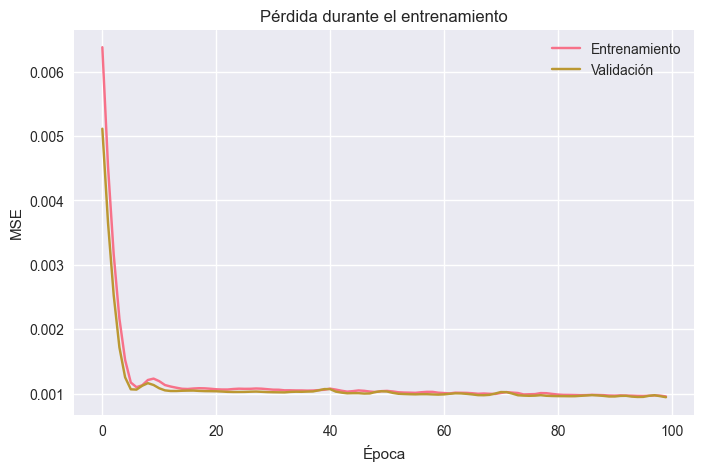

In [57]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()